<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB09 · Muchas cosas en una caja: las listas

**Parte 1 · Primeros pasos con el ordenador — Lección 5**

> En el **NB08** completaste las cuatro grandes piezas de la programación: orden, memoria, repetición y
> decisión. Con ellas la pelota rebota, el termostato decide y el episodio termina cuando el robot se
> cae. Pero hay un problema práctico que no podemos aplazar más: **nuestro robot tiene 17 motores**.

En el NB06 calculamos el esfuerzo de los motores con tres cajas sueltas: `motor_1`, `motor_2` y
`motor_3`. Para el humanoide de verdad harían falta **17** cajas para la acción y **45** para la
observación (NB03). Y con cada una habría que escribir su propia línea de cálculo. Sería un desastre.

Hoy aprenderás la solución: las **listas**, cajas que guardan **muchos valores a la vez, en orden**. Con
ellas, los 17 números de la acción del humanoide caben en **una sola caja**, y un bucle los recorre todos.
Y de propina, grabaremos la **trayectoria** completa de la pelota que rebota, para estudiarla después; y en
la práctica final grabarás y **dibujarás** la caída del humanoide en MuJoCo.

Una idea nueva por celda. Vamos.


## 1 · La idea: una estantería con huecos numerados

Una variable normal (NB06) es una caja que guarda **un** valor. Una **lista** es como una **estantería**
con varios huecos en fila, cada uno con su número, y todos bajo **una sola etiqueta**:

```
   etiqueta:  accion
             ┌───────┬───────┬───────┐
   valores:  │  0.4  │ -0.4  │  0.1  │
             └───────┴───────┴───────┘
   posición:     0       1       2         ← ¡se cuenta desde 0, como en range!
```

Los valores están **en orden**, y cada uno tiene una **posición** fija (el primero, el segundo...). A
cada valor de la lista se le llama **elemento**, y a su posición, **índice**. Y sí: como en `range`
(NB07), **el primer índice es el 0**.

Así es exactamente como el simulador maneja al humanoide: su acción es **una lista de 17 números** (uno
por motor, cada uno en su posición) y su observación, **una lista de 45**.


## 2 · Crear una lista

Una lista se escribe con **corchetes** `[ ]`, con los valores dentro **separados por comas**. Esta celda
crea una lista con la acción de 3 motores (los mismos valores que en el NB06) y la muestra:


In [1]:
accion = [0.4, -0.4, 0.1]
print(accion)

[0.4, -0.4, 0.1]


`print` muestra la lista entera, con sus corchetes y sus comas. Una sola caja, `accion`, con tres
números dentro, en orden.

(Aquí las comas **separan elementos**: dentro de los corchetes, `[1, 25]` es una lista de dos números, el
1 y el 25. Otra razón más para escribir los decimales con **punto**, como vimos en el NB05.)


## 3 · ¿Cuántos elementos tiene? `len`

Para saber cuántos elementos hay en una lista se usa **`len`** (de *length*, "longitud"):

In [2]:
print(len(accion))

3


**3**. Para la acción del humanoide, `len` daría 17; para su observación, 45. Es la manera de preguntarle
a una lista "¿cuánto mides?".


## 4 · Sacar un elemento: el índice

Para coger **un** elemento concreto, se escribe el nombre de la lista y, entre corchetes, su **índice**
(su posición). El **primero** es el de índice **0**:


In [3]:
print(accion[0])

0.4


**0.4**, el primer elemento. Y el **tercero** es el de índice... **2** (0, 1, 2):

In [4]:
print(accion[2])

0.1


**0.1**. Grábate la regla, que es la misma de `range`:

```
   en una lista de 3 elementos, los índices son 0, 1 y 2.
   el primer elemento es lista[0]; el último es lista[len - 1].
```

Es como las plantas de un edificio (NB07): en un edificio de 3 plantas, la última es la planta 2.


### ¿Y si pido un hueco que no existe?

La lista tiene 3 elementos (índices 0, 1 y 2). ¿Qué pasa si pedimos el de índice 3?

In [5]:
print(accion[3])

IndexError: list index out of range

`IndexError: list index out of range`: "**error de índice**: el índice de la lista está **fuera de
rango**". Has pedido un hueco de la estantería que no existe. Es un error típico cuando se olvida que se
cuenta desde 0: en una lista de 3, el `3` ya se sale.

| Tipo de error | Qué suele significar |
|---|---|
| `NameError` | Nombre desconocido |
| `SyntaxError` | Gramática rota |
| `IndentationError` | Sangría que falta o sobra |
| `IndexError` | Has pedido una posición que la lista no tiene |


## 5 · Contar desde el final: índices negativos

Un truco muy práctico: los índices **negativos** cuentan **desde el final**. `-1` es el **último**
elemento, `-2` el penúltimo, etc. Así puedes coger el último sin saber cuánto mide la lista:


In [6]:
print(accion[-1])

0.1


**0.1**, el último. Será muy útil, por ejemplo, para mirar **la última altura** de una trayectoria
grabada (lo haremos más abajo).

```
   índice positivo:     0      1      2
                     ┌──────┬──────┬──────┐
                     │ 0.4  │ -0.4 │ 0.1  │
                     └──────┴──────┴──────┘
   índice negativo:    -3     -2     -1
```


## 6 · Cambiar un elemento

Cada hueco de la estantería funciona como una caja normal: puedes **guardar** un valor nuevo en él con
`=` (NB06). Esta celda cambia el elemento de índice 1 (el segundo) por 0,2:


In [7]:
accion[1] = 0.2
print(accion)

[0.4, 0.2, 0.1]


El −0,4 de la posición 1 se ha sustituido por 0,2; los demás siguen igual. Es como si la mente del
robot cambiara de opinión solo sobre el motor número 1.


## 7 · Recorrer una lista con `for`

Aquí está la gran ventaja de las listas. El bucle `for` del NB07 no solo sirve con `range`: puede
recorrer **directamente los elementos de una lista**, uno detrás de otro. En cada vuelta, la variable del
bucle vale el **siguiente elemento**:


In [8]:
for valor in accion:
    print(valor)

0.4
0.2
0.1


Una vuelta por elemento: primero 0.4, luego 0.2, luego 0.1. Se lee como en castellano: "**para cada**
valor **en** la acción, muéstralo".

```
   for valor in accion:        vuelta 1: valor = 0.4
       print(valor)            vuelta 2: valor = 0.2
                               vuelta 3: valor = 0.1
```

Si la lista tuviera 17 elementos, daría 17 vueltas, sin cambiar ni una letra del código.


## 8 · El esfuerzo de los motores, con una lista

Ahora juntamos las listas con el **acumulador** del NB07. El esfuerzo de un paso (NB04) era: **cada
acción al cuadrado, y todo sumado**. Con una lista, es una hucha que recorre los motores. Volvemos a la
acción original del NB06, `[0.4, -0.4, 0.1]`, que daba un esfuerzo de 0,33:


In [9]:
accion = [0.4, -0.4, 0.1]

esfuerzo = 0
for a in accion:
    esfuerzo = esfuerzo + a ** 2

print("Esfuerzo:", round(esfuerzo, 2))

Esfuerzo: 0.33


**0.33**, como en el NB06. Pero compara cómo lo hacíamos allí:

```
   NB06:   esfuerzo = motor_1 ** 2 + motor_2 ** 2 + motor_3 ** 2      (una cosa por motor)
   NB09:   for a in accion:
               esfuerzo = esfuerzo + a ** 2                           (sirve para CUALQUIER número de motores)
```

La versión con lista **no depende de cuántos motores haya**. Y eso nos permite, por fin, ir a por el
humanoide entero.


### Los 17 motores del humanoide

Esta es una acción completa de nuestro humanoide: **17 números**, uno por motor, cada uno entre −0,4 y
+0,4 (NB03). Los números son inventados, pero el formato es exactamente el real. El código del esfuerzo
es **idéntico** al de la celda anterior; solo cambia la lista:


In [10]:
accion = [0.1, -0.3, 0.0, -0.2, 0.4, 0.1, -0.4, 0.0, -0.1, 0.3, 0.2, 0.1, 0.0, -0.1, 0.0, 0.2, 0.0]
print("Número de motores:", len(accion))

esfuerzo = 0
for a in accion:
    esfuerzo = esfuerzo + a ** 2

print("Esfuerzo:", round(esfuerzo, 2))
print("Castigo por esfuerzo:", round(0.1 * esfuerzo, 3), "puntos")

Número de motores: 17
Esfuerzo: 0.67
Castigo por esfuerzo: 0.067 puntos


17 motores, esfuerzo **0,67** y un castigo de **0,067 puntos** (el −0,1 × esfuerzo del NB04). Con el
**mismo** código de 3 líneas que para 3 motores. Esto es lo que hace el simulador del humanoide en cada
paso, 67 veces por segundo.


## 9 · Órdenes listas para usar: `sum`, `max` y `min`

Sumar los elementos de una lista es tan común que Python trae una orden hecha: **`sum`** ("suma"). Y
otras dos muy útiles: **`max`** (el mayor) y **`min`** (el menor). Cada una recibe la lista entre
paréntesis, igual que `len`:


In [11]:
print("Suma:", round(sum(accion), 2))
print("La acción más grande:", max(accion))
print("La acción más pequeña:", min(accion))

Suma: 0.3
La acción más grande: 0.4
La acción más pequeña: -0.4


La suma de las 17 acciones es 0,3 (los positivos y los negativos se compensan casi del todo). La más
grande es **0.4** (el motor que más fuerte empuja hacia un lado) y la más pequeña **−0.4** (el que más
fuerte empuja hacia el otro).

¿Y la **media**, el valor "típico"? Es la suma dividida entre cuántos hay: `sum(lista) / len(lista)`.
La usaremos muchísimo, por ejemplo para saber cuántos puntos saca **de media** un robot en varios
episodios (lo haremos en el NB11).

Fíjate en algo: `print`, `round`, `len`, `sum`, `max`, `min`... Todas son **órdenes con nombre** que
reciben cosas entre paréntesis y hacen un trabajo. Se llaman **funciones**, y en el próximo notebook
aprenderás a **crear las tuyas**.


## 10 · Una lista que va creciendo: `append`

Hasta ahora escribíamos la lista entera de golpe. Pero muchas veces no sabemos de antemano qué valores
tendrá: por ejemplo, las alturas de la pelota, que se van calculando paso a paso. Para eso se empieza con
una lista **vacía**, `[]`, y se le van **añadiendo** elementos al final.

Primero, una lista vacía:


In [12]:
trayectoria = []
print(trayectoria, "tiene", len(trayectoria), "elementos")

[] tiene 0 elementos


Una estantería sin nada: `[]`, con 0 elementos. Ahora le **añadimos** dos alturas. Se escribe así, con
un **punto** entre el nombre de la lista y la orden **`append`** ("añadir al final"):


In [13]:
trayectoria.append(2.0)
trayectoria.append(1.9)
print(trayectoria)

[2.0, 1.9]


Cada `append` ha añadido un elemento **al final**: primero el 2.0, luego el 1.9.

¿Por qué esta forma tan rara, `trayectoria.append(...)`, con un punto? Porque `append` es una orden que
**pertenece a las listas**: se le pide **a una lista concreta** que se añada algo a sí misma. Léelo como
"trayectoria, **añádete** el 2.0". A las órdenes que pertenecen a algo y se escriben con un punto se les
llama **métodos**. Las listas tienen unos cuantos; `append` es, con diferencia, el más usado.


## 11 · Grabar la trayectoria de la pelota

Ahora, la aplicación estrella: **grabar todo lo que hace la pelota** del NB08, la que rebota. En vez de
mostrar mensajes, en cada pasito **añadimos la altura a una lista**. Al final tendremos la trayectoria
completa, como una "película" en números, para estudiarla con calma.

Es el simulador del NB08 con **dos** líneas nuevas: la lista vacía antes del bucle, y el `append` al
final de cada vuelta:


In [14]:
gravedad = 10
paso_tiempo = 0.01
altura = 2.0
velocidad = 0.0

alturas = []                                  # NUEVO: la "película", vacía

for paso in range(300):
    velocidad = velocidad + gravedad * paso_tiempo
    altura = altura - velocidad * paso_tiempo
    if altura < 0:
        altura = 0
        velocidad = -velocidad * 0.8
    alturas.append(altura)                    # NUEVO: graba la altura de este pasito

print("Fotos grabadas:", len(alturas))

Fotos grabadas: 300


**300 fotos**: una altura por cada pasito de los 3 segundos. Toda la caída y los botes, guardados en una
sola caja. Ahora podemos hacerle preguntas a la película. Por ejemplo, ¿cuál fue la altura más alta y la
más baja?


In [15]:
print("Altura máxima:", max(alturas))
print("Altura mínima:", min(alturas))

Altura máxima: 1.999
Altura mínima: 0


La máxima es **1.999** (la primera foto, justo después de soltarla: ya ha bajado 1 milímetro) y la
mínima, **0** (las veces que tocó el suelo).


### Coger un trozo de la lista

A veces queremos solo **una parte** de la lista, por ejemplo las 5 primeras fotos. Se escribe
`lista[inicio:fin]`, con dos puntos entre medias, y sigue **la misma regla que `range`**: empieza en
`inicio` y para **antes** de `fin`:


In [16]:
print(alturas[0:5])

[1.999, 1.997, 1.9940000000000002, 1.9900000000000002, 1.9850000000000003]


Las 5 primeras alturas: las de índices 0, 1, 2, 3 y 4. (Con su ruido de decimales en algunas,
nuestro viejo amigo del NB06.) Se ve cómo la pelota empieza a caer despacio y va cogiendo velocidad: baja
1 mm, luego 2, luego 3, luego 4, luego 5... la inercia y la gravedad en acción.

A un trozo de lista se le llama **porción** (en inglés, *slice*, "rebanada").


### ¿Dónde está el primer bote?

En el NB08, el primer bote salió "en el paso 63". Pero allí contábamos los pasos desde el **1**
(`range(1, 301)`). Aquí la lista empieza en el índice **0**. Así que el paso 63 debería estar en el
índice **62**. Miremos los índices 61, 62 y 63:


In [17]:
print(alturas[61], alturas[62], alturas[63])

0.04700000000000226 0 0.04939999999999996


¡Ahí está! En el índice 61 la pelota está a punto de llegar (a unos 5 cm del suelo), en el **62** está
en el **suelo (0)**, y en el 63 ya ha empezado a subir. El "paso 63" del NB08 es el índice 62 de la lista:
la eterna diferencia entre contar desde 1 (las personas) y desde 0 (Python). Acostúmbrate a hacer esta
"traducción" de cabeza, porque la harás toda la vida.


### ¿Cuánto sube tras el primer bote?

La pelota se soltó desde 2 metros, pero al rebotar pierde un 20 % de velocidad. ¿Hasta dónde llega en el
primer rebote? Basta con buscar la altura máxima **después** del primer bote, por ejemplo entre los
índices 100 y 300 (cuando ya ha rebotado y aún no ha botado otra vez... o sí; da igual, porque después
del primer rebote los siguientes son aún más bajos):


In [18]:
print("Altura máxima tras el primer bote:", round(max(alturas[100:300]), 2), "metros")

Altura máxima tras el primer bote: 1.24 metros


**1,24 metros**, bastante menos que los 2 iniciales. Un 20 % menos de velocidad se convierte en casi
un **40 %** menos de altura. (¿Por qué tanto? Porque la altura que alcanza algo lanzado hacia arriba
depende de la velocidad **al cuadrado**: 0,8² = 0,64, y 2 × 0,64 = 1,28 m; nuestro simulador da 1,24
por el error de los pasos de 0,01 s que mediste en el NB07. El cuadrado otra vez, como en el NB04.)


### Contar con una condición

Una pregunta más: ¿**cuántas fotos** de las 300 tienen la pelota por encima de 1 metro? Es un
**acumulador** (NB07) que solo suma cuando se cumple un `if` (NB08), recorriendo la lista (hoy):


In [19]:
fotos_altas = 0
for h in alturas:
    if h > 1.0:
        fotos_altas = fotos_altas + 1

print("Fotos por encima de 1 metro:", fotos_altas, "de", len(alturas))

Fotos por encima de 1 metro: 89 de 300


**89** de 300: la pelota pasa menos de un tercio del tiempo por encima del metro. Fíjate en que esta celda
combina **cuatro** cosas que has aprendido en cuatro lecciones distintas (variables, bucles, decisiones y
listas), y se lee de corrido. Así es programar: piezas sencillas, combinadas.

Esto es **exactamente** lo que hacen los profesionales con sus robots: **grabar** todo lo que pasa en un
episodio (alturas del torso, velocidades, recompensas...) y luego **hacerle preguntas a la grabación**:
¿cuánto aguantó?, ¿cuál fue la recompensa media?, ¿en qué paso empezó a caerse? (Es la costumbre del
NB04: "mide aparte lo que de verdad quieres".)


## 12 · Dos listas en paralelo

Una última idea. A veces tenemos **dos listas que van emparejadas**: por ejemplo, los **nombres** de unos
motores y sus **valores**. El elemento 0 de una va con el elemento 0 de la otra, el 1 con el 1, etc. Para
recorrerlas juntas, se usa un `for` sobre los **índices**, con `range(len(...))`: así `i` vale 0, 1, 2...
y con él sacamos el elemento correspondiente de **cada** lista. (Fíjate también en que una lista puede
guardar **texto**, no solo números.)


In [20]:
nombres = ["cadera", "rodilla", "hombro"]
valores = [0.3, -0.4, 0.1]

for i in range(len(nombres)):
    print(nombres[i], "->", valores[i])

cadera -> 0.3
rodilla -> -0.4
hombro -> 0.1


`range(len(nombres))` es `range(3)`, es decir, 0, 1, 2: los índices válidos de la lista. En cada vuelta,
`nombres[i]` y `valores[i]` son la pareja que va junta.

```
   i = 0:   nombres[0] = "cadera"    valores[0] = 0.3
   i = 1:   nombres[1] = "rodilla"   valores[1] = -0.4
   i = 2:   nombres[2] = "hombro"    valores[2] = 0.1
```

El simulador del humanoide hace algo así por dentro: tiene una lista con los nombres de los 17 motores
(`"abdomen_y"`, `"right_hip_x"`, `"right_knee"`...) y la acción es la lista de valores que va emparejada
con ella, en el mismo orden. Por eso **el orden de la acción importa**: si te equivocas de posición,
¡mueves la rodilla cuando querías mover el hombro!


## 13 · Resumen de la lección

1. Una **lista** guarda muchos valores en orden en una sola caja: `accion = [0.4, -0.4, 0.1]`. Cada valor
   es un **elemento**; su posición, el **índice**, que **empieza en 0**.
2. `len(lista)` dice cuántos elementos hay; `lista[i]` saca uno (con `-1` el último); `lista[i] = valor`
   lo cambia; pedir un índice que no existe da **`IndexError`**.
3. **`for x in lista:`** recorre los elementos uno a uno. Con un acumulador, el **esfuerzo** de los 17
   motores se calcula con el mismo código que el de 3. `sum`, `max` y `min` vienen hechas; la **media** es
   `sum / len`.
4. Se empieza con `[]` y se añade al final con el **método** `lista.append(valor)`. Así se **graba una
   trayectoria** y luego se le hacen preguntas (máximo, porciones `lista[inicio:fin]`, contar con `if`).
5. Dos listas emparejadas se recorren con `for i in range(len(lista)):`. La acción y la observación del
   humanoide **son listas**, y el orden de sus elementos importa.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Lista** | Una caja con muchos valores en orden: `[1, 2, 3]`. |
| **Elemento** | Cada valor guardado en una lista. |
| **Índice** | La posición de un elemento (empieza en 0). |
| **`len`** | Cuántos elementos tiene una lista. |
| **`IndexError`** | Error por pedir una posición que no existe. |
| **`sum` / `max` / `min`** | Suma / mayor / menor de los elementos. |
| **Media** | La suma dividida entre cuántos hay: el valor "típico". |
| **`append`** | Añade un elemento al final de una lista. |
| **Método** | Una orden que pertenece a algo y se escribe con un punto: `lista.append(...)`. |
| **Porción (*slice*)** | Un trozo de una lista: `lista[inicio:fin]`. |
| **Trayectoria** | La grabación de cómo cambia algo a lo largo del tiempo. |
| **Función** | Una orden con nombre que recibe cosas entre paréntesis y hace un trabajo. |


## 14 · Ejercicios

**E1.** Crea una lista `masas` con las masas (en kilos) de cuatro piezas del humanoide: torso 8,91;
pelvis 6,62; muslo 4,75; pantorrilla 2,76. Muestra cuántas hay y la masa de la **pelvis** usando su índice.

**E2.** Con la lista `masas`, calcula la **suma** de las cuatro masas y la pieza **más pesada**.

**E3.** Predice: si `x = [10, 20, 30, 40, 50]`, ¿qué muestran `print(x[1])`, `print(x[-2])`,
`print(x[1:3])` y `print(len(x))`?

**E4.** ¿Qué error da `x[5]` con la lista del ejercicio anterior? ¿Por qué?

**E5.** Escribe un bucle que recorra la acción de los 17 motores del apartado 8 y **cuente cuántos motores
están parados** (con valor exactamente 0).

**E6.** Calcula la **media** de estas recompensas de cinco pasos: `[5.2, 4.9, 6.1, 5.5, 5.8]`.

**E7.** Empieza con una lista vacía `retornos = []` y añádele con `append` los retornos de los robots A, B,
C y D del NB04 (98, 198, 5000, 6150). Luego muestra el mejor.

**E8.** **Reto.** Modifica el simulador de la pelota para que, además de las alturas, grabe las
**velocidades** en otra lista `velocidades`. ¿Cuál es la velocidad **máxima hacia abajo** (la más grande
positiva) que alcanza?


<details>
<summary>▶ Solución E1</summary>

```python
masas = [8.91, 6.62, 4.75, 2.76]
print(len(masas))
print(masas[1])
```

Salida: `4` y `6.62`. La pelvis es la **segunda** pieza, así que su índice es **1** (se cuenta desde 0).
</details>

<details>
<summary>▶ Solución E2</summary>

```python
print(round(sum(masas), 2))
print(max(masas))
```

Salida: **23.04** kilos en total y **8.91** la más pesada (el torso). (Sin el `round`, la suma podría
salir con un poco de ruido de decimales.)
</details>

<details>
<summary>▶ Solución E3</summary>

- `x[1]` → **20** (el segundo; índice 1).
- `x[-2]` → **40** (el penúltimo).
- `x[1:3]` → **[20, 30]** (índices 1 y 2; para **antes** del 3).
- `len(x)` → **5**.
</details>

<details>
<summary>▶ Solución E4</summary>

Da **`IndexError: list index out of range`**. La lista tiene 5 elementos, así que sus índices van del **0
al 4**. El índice 5 sería un sexto elemento, que no existe.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
parados = 0
for a in accion:
    if a == 0:
        parados = parados + 1
print("Motores parados:", parados)
```

Salida: **5** motores parados (los de valor 0.0). Es un acumulador con un `if` dentro, igual que el de las
fotos por encima de 1 metro.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
recompensas = [5.2, 4.9, 6.1, 5.5, 5.8]
media = sum(recompensas) / len(recompensas)
print(round(media, 2))
```

Salida: **5.5**. La suma es 27,5 y hay 5 valores: 27,5 / 5 = 5,5.
</details>

<details>
<summary>▶ Solución E7</summary>

```python
retornos = []
retornos.append(98)
retornos.append(198)
retornos.append(5000)
retornos.append(6150)
print(retornos)
print("El mejor:", max(retornos))
```

Salida: `[98, 198, 5000, 6150]` y **El mejor: 6150** (el robot D, el que anda).
</details>

<details>
<summary>▶ Solución E8</summary>

```python
gravedad = 10
paso_tiempo = 0.01
altura = 2.0
velocidad = 0.0
alturas = []
velocidades = []

for paso in range(300):
    velocidad = velocidad + gravedad * paso_tiempo
    altura = altura - velocidad * paso_tiempo
    if altura < 0:
        altura = 0
        velocidad = -velocidad * 0.8
    alturas.append(altura)
    velocidades.append(velocidad)

print(round(max(velocidades), 2))
```

Sale **6,2 m/s**: la velocidad justo antes del primer bote (la física exacta dice 6,32; la diferencia es
el error de los pasos de 0,01 s del NB07), que es la más rápida de todo el recorrido
(después de cada bote, la pelota cae desde más bajo y llega más despacio). Los valores **negativos** de la
lista son los momentos en que sube.
</details>


## 15 · 🛠 Práctica en MuJoCo: graba la caída y dibújala

En el apartado 11 grabaste la "película" de tu pelota en una lista y le hiciste preguntas. Hoy vas
a hacer lo mismo con MuJoCo: **grabar la altura del torso del humanoide en cada pasito**, hacerle
preguntas a la grabación con `len`, `max`, `min`, índices y porciones, y, por primera vez,
**dibujarla**. A una grabación así los ingenieros la llaman **trayectoria**.


### Paso 1 · Grabar la trayectoria

Tu bucle de simulación del NB07, con las **dos líneas nuevas** del apartado 11: la lista vacía antes
del bucle y el `append` dentro. Simulamos **2 segundos** (667 pasitos de 0,003 s):


In [21]:
import mujoco
import taller

modelo, datos = taller.cargar("humanoide")

alturas = []                                  # la "película", vacía
for paso in range(667):
    mujoco.mj_step(modelo, datos)
    alturas.append(datos.qpos[2])             # graba la altura del torso en este pasito

print("Fotos grabadas:", len(alturas))

Fotos grabadas: 667


**667 fotos**, una por pasito. Ahora, las preguntas del apartado 11, a la grabación de MuJoCo:

In [22]:
print("Altura máxima:", round(max(alturas), 3), "m")
print("Altura mínima:", round(min(alturas), 3), "m")
print("Primera foto:", round(alturas[0], 3), "| última foto:", round(alturas[-1], 3))

Altura máxima: 1.4 m
Altura mínima: 0.079 m
Primera foto: 1.4 | última foto: 0.08


La máxima es casi la de salida (1,4 m) y la mínima, unos **0,08 m**: el torso tumbado en el suelo.
La última foto (índice `-1`, apartado 5) dice dónde acabó a los 2 segundos.

Y una **porción** (apartado 11): las 5 primeras fotos.


In [23]:
for h in alturas[0:5]:
    print(round(h, 5))

1.39996
1.39982
1.3996
1.39929
1.39889


1,39996 → 1,39982 → 1,39960 → 1,39929 → 1,39889: en los cinco primeros pasitos el torso baja **ni un
milímetro**, pero cada vez un poco más deprisa (la gravedad empezando a ganar, como en tu pelota). (Recorremos
la porción con un `for` y redondeamos cada número porque, con `print(alturas[0:5])` a secas, MuJoCo enseña sus
números con una etiqueta técnica, `np.float64(...)`, que lo ensucia todo; la entenderás en el NB15.)


### Paso 2 · ¿En qué foto se cayó?

En el NB08 viste que el humanoide quieto se cae (torso por debajo de 1 m) en el **paso 200**. Busquémoslo
en la grabación: recorremos los índices con `range(len(...))` (apartado 12) y paramos en el primero que
esté por debajo de 1 metro (`if` y `break`, NB08):


In [24]:
for i in range(len(alturas)):
    if alturas[i] < 1.0:
        print("Primera foto por debajo de 1 m: índice", i, "-> altura", round(alturas[i], 3))
        break

Primera foto por debajo de 1 m: índice 199 -> altura 0.997


**Índice 199**. ¿Y no era el paso 200? ¡Sí! Es la "traducción" del apartado 11: el paso 200 (contando
desde 1, como en el NB08) es el índice 199 (contando desde 0, como Python). La misma caída, vista desde
la grabación.

Y una pregunta con acumulador + `if` (apartado 11): ¿cuántas fotos tiene el torso **por encima** de 1 m?


In [25]:
fotos_de_pie = 0
for h in alturas:
    if h > 1.0:
        fotos_de_pie = fotos_de_pie + 1

print("Fotos de pie:", fotos_de_pie, "de", len(alturas))

Fotos de pie: 199 de 667


**199 de 667**: menos de un tercio del tiempo de pie, y luego, al suelo. Si cada una de esas fotos valiera
los +5 puntos del NB04, ya sabrías cuánto puntúa el robot quieto antes de caerse.


### Paso 3 · Dibujarla

Mirar 667 números es imposible; un **dibujo** lo dice todo de un vistazo. Para dibujar se usa otra caja
de herramientas, **matplotlib** (las tres primeras líneas la sacan del armario; lo de `import ... as plt`
lo explica el NB11b). La línea importante es **`plt.plot(alturas)`**: "dibuja esta lista como una línea".
El resto pone títulos y una raya horizontal en 1 metro:


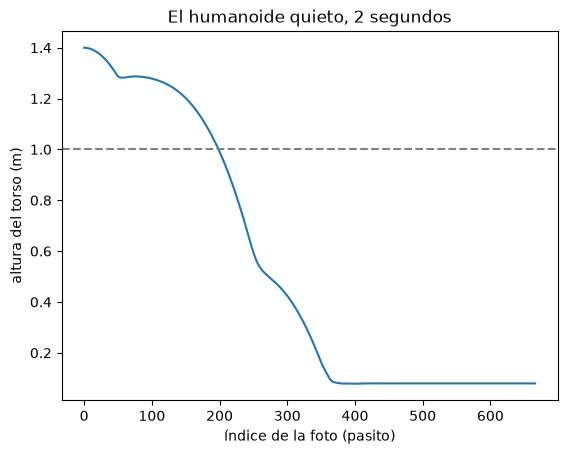

In [26]:
import matplotlib.pyplot as plt

plt.plot(alturas)
plt.axhline(1.0, color="gray", linestyle="--")         # la raya de "se ha caído"
plt.xlabel("índice de la foto (pasito)")
plt.ylabel("altura del torso (m)")
plt.title("El humanoide quieto, 2 segundos")
plt.show()

Así es la caída entera: primero un pequeño hundimiento (hasta 1,28 m, hacia la foto 50: el cuerpo se
"asienta" doblando cintura y rodillas), un rato casi quieto, después el desplome, que cruza la raya de 1
metro en el índice 199, y hacia la foto 370 el torso queda tumbado a unos 8 cm del suelo, ya sin moverse. Una lista + `plt.plot` = una trayectoria que se entiende de un vistazo.


### Paso 4 · Dos trayectorias, un dibujo

Ahora grabamos **otra** película: el robot con **motores al azar** (el mando `taller.al_azar` del NB08),
en una lista distinta. Luego dibujamos las dos juntas: cada `plt.plot` añade una línea, y `label` le pone
nombre para la leyenda:


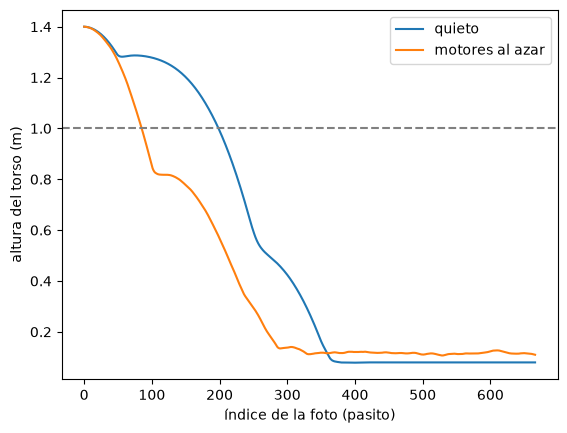

In [27]:
modelo, datos = taller.cargar("humanoide")
control = taller.al_azar(0)

alturas_azar = []
for paso in range(667):
    control(modelo, datos)
    mujoco.mj_step(modelo, datos)
    alturas_azar.append(datos.qpos[2])

plt.plot(alturas, label="quieto")
plt.plot(alturas_azar, label="motores al azar")
plt.axhline(1.0, color="gray", linestyle="--")
plt.xlabel("índice de la foto (pasito)")
plt.ylabel("altura del torso (m)")
plt.legend()
plt.show()

La línea del azar **cruza la raya antes** (en el NB08 lo mediste: paso 86) y no se queda tan quieta en
el suelo: los motores siguen sacudiendo el cuerpo tumbado. Comparar políticas **dibujando sus
trayectorias** es una de las cosas que más hacen los ingenieros de robótica.


### Paso 5 · Una pelota de MuJoCo que rebota

En el apartado 11 tu pelota rebotaba con un 0,8. ¿Y la de MuJoCo? Por defecto, su suelo es de
"plastilina" (NB02). Pero se puede hacer **botón**: en el plano de abajo, la pelota lleva un ajuste
nuevo, `solref="-10000 -14"`. Son las dos cifras del **choque** con el suelo: lo **duro** que es
(10000, como un muelle muy rígido) y cuánto **frena** (14, como un amortiguador). Los entenderás de
verdad en el NB39b (muelles y amortiguadores). Hoy, solo grabamos lo que pasa: 300 fotos con pasitos de
0,01 s, como en el apartado 11:


In [28]:
PELOTA_BOTONA = '''
<mujoco>
  <option gravity="0 0 -10" timestep="0.01"/>
  <worldbody>
    <light pos="0 0 5"/>
    <geom type="plane" size="5 5 0.1" rgba=".8 .9 .8 1"/>
    <body name="pelota" pos="0 0 2">
      <freejoint/>
      <geom type="sphere" size="0.05" rgba="1 .3 .1 1" solref="-10000 -14"/>
    </body>
  </worldbody>
</mujoco>
'''

modelo, datos = taller.cargar(PELOTA_BOTONA)
alturas_pelota = []
for paso in range(300):
    mujoco.mj_step(modelo, datos)
    alturas_pelota.append(datos.qpos[2])

print("Fotos:", len(alturas_pelota))
print("Índices 61, 62, 63:", round(alturas_pelota[61], 3), round(alturas_pelota[62], 3), round(alturas_pelota[63], 3))
print("Altura máxima tras el primer bote:", round(max(alturas_pelota[100:300]), 2), "m")

Fotos: 300
Índices 61, 62, 63: 0.047 -0.003 0.007
Altura máxima tras el primer bote: 1.38 m


El primer bote está en el **índice 62**, exactamente donde lo encontraste con tu pelota en el apartado
11 (las dos caen igual, con la misma receta y el mismo paso). Las alturas son las del **centro** de la
pelota, así que tocar el suelo sería 0,05 m (su radio); en el índice 62 marca −0,003: durante el choque
la pelota **se hunde** unos 5 cm en el suelo, porque con pasitos de 0,01 s un choque tan duro se calcula
de forma bastante gruesa. Tras el bote sube hasta **1,38 m**: con estos
dos números de choque, la pelota de MuJoCo es algo más botona que la tuya (1,24 m). Para verlo, las
dos películas en un dibujo (tu lista `alturas` del apartado 11 ya no existe, porque el Paso 1 reutilizó
ese nombre; así que la recalculamos, ya escrita, con tu receta del apartado 11):


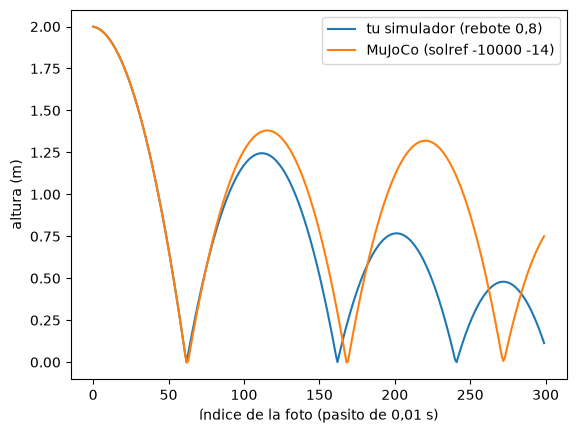

In [29]:
altura = 2.0
velocidad = 0.0
alturas_tuyas = []
for paso in range(300):
    velocidad = velocidad + 10 * 0.01
    altura = altura - velocidad * 0.01
    if altura < 0:
        altura = 0
        velocidad = -velocidad * 0.8
    alturas_tuyas.append(altura)

plt.plot(alturas_tuyas, label="tu simulador (rebote 0,8)")
plt.plot(alturas_pelota, label="MuJoCo (solref -10000 -14)")
plt.xlabel("índice de la foto (pasito de 0,01 s)")
plt.ylabel("altura (m)")
plt.legend()
plt.show()

Las dos curvas caen **pegadas** hasta el primer bote; después, la de MuJoCo sube un poco más (1,38 m
contra 1,24) y, sobre todo, en el **segundo** bote apenas pierde altura (vuelve a 1,32 m), mientras la
tuya baja a 0,77. Tu rebote quita **siempre** un 20 % de velocidad; el choque de MuJoCo no funciona así:
cuánto devuelve depende de cómo llegue la pelota y de lo grueso del paso de tiempo. La lista y el dibujo
te lo han enseñado sin una sola cuenta. Lo que en tu simulador era **una línea** (`-velocidad * 0.8`), en
MuJoCo son **dos números del choque**.


### Tus retos

**Reto 1.** Con la lista `alturas_azar` del Paso 4, busca el primer índice por debajo de 1 m (copia la
celda del Paso 2 cambiando el nombre de la lista). ¿Cuadra con el paso 86 del NB08?

**Reto 2.** ¿Cuál es la altura **media** del torso en esos 2 segundos, quieto? Usa `sum` y `len`
(apartado 9).

**Reto 3.** Graba además los **motores**: en MuJoCo, el nombre del motor número `i` es
`modelo.actuator(i).name`. Construye una lista `nombres` con los 17 nombres usando un `for` con
`range(modelo.nu)` y `append`, y muestra los 3 primeros con una porción.

**Reto 4.** En el Paso 5, cambia el freno del choque a `solref="-10000 -20"`. ¿Sube más o menos tras el
primer bote?

<details>
<summary>▶ Solución Reto 1</summary>

```python
for i in range(len(alturas_azar)):
    if alturas_azar[i] < 1.0:
        print(i)
        break
```

Sale el índice **85**: el paso 86 del NB08 contado desde 0. Cuadra.
</details>

<details>
<summary>▶ Solución Reto 2</summary>

```python
print(round(sum(alturas) / len(alturas), 2))
```

Unos **0,54 m**: el robot pasa la mayor parte de esos 2 segundos en el suelo.
</details>

<details>
<summary>▶ Solución Reto 3</summary>

```python
nombres = []
for i in range(modelo.nu):
    nombres.append(modelo.actuator(i).name)
print(len(nombres), nombres[0:3])
```

(Si el último modelo cargado es la pelota, que no tiene motores, sale una lista vacía: carga antes el
humanoide con `modelo, datos = taller.cargar("humanoide")`.) Sale **17** y `['abdomen_y', 'abdomen_z',
'abdomen_x']`: la lista de nombres que va emparejada con la acción (apartado 12).
</details>

<details>
<summary>▶ Solución Reto 4</summary>

**Menos**: con más freno, el choque se come más energía y la pelota sube solo hasta unos **1,15 m**. Con
estos números se ajusta lo "botón" que es un suelo, igual que tu 0,8.
</details>

### Qué has aprendido de MuJoCo hoy

- **Grabar una trayectoria**: lista vacía antes del bucle + `append(datos.qpos[2])` dentro.
- Hacerle preguntas: `len`, `max`, `min`, índices, porciones; el paso 200 es el **índice 199**.
- **Dibujarla** con `plt.plot(lista)`, y comparar dos políticas (quieto vs azar) en el mismo dibujo.
- El rebote en MuJoCo se ajusta con los números del choque (`solref`); el primer bote cae en el mismo
  índice (62) que el de tu simulador.

En la práctica del NB10 meterás todo esto en una **función**, `caida(gravedad)`, que devuelve el tiempo
que tarda el humanoide en caerse, y la usarás para comparar la Luna, Marte, la Tierra y Júpiter.


## 16 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Ahora ya puedes manejar la acción y la observación del humanoide **tal y como son**: listas de números. Y
sabes grabar lo que pasa en una simulación para estudiarlo después, que es media vida de un ingeniero de
robótica.

En el **NB10** aprenderás a crear tus propias **funciones**: órdenes con nombre, como `len` o `sum`, pero
hechas por ti. Con ellas podremos meter la recompensa, el pasito de física y, sobre todo, **la política**,
cada una en su propia "caja con nombre" que se usa una y otra vez. Y verás que la política del NB03, esa
caja que convierte una observación en una acción, **es literalmente una función**.
